# `own_night_arc` 45장 — 6종 모델 성능·용량 비교

`data/own_night_arc`(`data/own_night`의 고정 스냅샷 — 45장, `own_night_KU` 병합 후)에서
6종을 같은 자로 비교한다: `c4d_11n_640` · `c4e_s3_11n`(현 `C5` 1등 후보) · `c4e_s3_11n`
INT8 · `c4f_11s_640_teacher`(증류 교사) · `c4f_distill_11n_640`(증류 학생) · 학생 INT8.

성능 5축(mAP·운영점·음성 오탐·GT 폭구간별 recall·볼라드 박스별 conf)은
`scripts/eval_own_night.py` CLI가 이미 계산해 `outputs/detect/c5_own_night_arc_6way.json`에
저장해 뒀다 — 이 노트북은 **재계산 없이 그 캐시만 읽는다.** 용량(파일 크기)만 여기서
새로 잰다(CLI에는 없는 축).

⚠️ 이 6종 중 4종(교사/학생 FP32·INT8, `c4e_s3_11n` FP32·INT8)은 `runpod_distillation_20260831.md`
§5-3에서 **구 27장**으로도 이미 비교됐다 — own_night(교사 우세)과 NightOwls rec34(학생
우세) 순위가 갈리는 이슈가 아직 미해결이다(`docs/STATUS.md` §1). 여기서는 **45장에서 어느
방향이 나오는지만 사실로 확인**한다 — 순위 역전 원인 규명은 여전히 `C11` 대기.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

_have = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
for _f in ("Malgun Gothic", "AppleGothic", "NanumGothic"):
    if _f in _have:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

# 성능(5축)은 아래 .pt 로 이미 돌아간 캐시(JSON)를 그대로 쓴다 — .pt/ONNX 는 그래프
# 포맷만 다르고 가중치는 같아 성능 수치는 사실상 동일하다(export 는 재계산이 아니다).
WEIGHTS = {
    "c4d_11n_640": ROOT / "outputs/detect/c4d_11n_640/weights/best.pt",
    "c4e_s3_11n": ROOT / "outputs/detect/c4e_s3_11n/weights/best.pt",
    "c4e_s3_11n_INT8": ROOT / "outputs/quantization/bammasil_det_c4e_s3_11n_640-INT8"
                              "/bammasil_det_c4e_s3_11n_640-INT8_generic.onnx",
    "c4f_11s_640_teacher": ROOT / "outputs/detect/c4f_11s_640_teacher/weights/best.pt",
    "c4f_distill_11n_640": ROOT / "outputs/detect/c4f_distill_11n_640/weights/best.pt",
    "c4f_distill_11n_640_INT8": ROOT / "outputs/quantization/bammasil_det_c4f_distill_11n_640_640-INT8"
                                       "/bammasil_det_c4f_distill_11n_640_640-INT8_generic.onnx",
}

# ⚠️ **용량은 `.pt`가 아니라 실제 배포 산출물(ONNX)로 잰다.** `.pt`는 ultralytics 학습
# 체크포인트 직렬화 포맷이라 ONNX 그래프보다 작게 나온다(예: c4e_s3_11n .pt 5.23MB vs
# ONNX 10.11MB — 같은 가중치인데 포맷만 다르다). INT8은 애초에 그 ONNX를 양자화한
# 것이므로, 압축비도 ONNX FP32 대 INT8로 재야 앞뒤가 맞는다.
SIZE_PATHS = {
    "c4d_11n_640": ROOT / "outputs/export/c4d_11n_640/bammasil_det_c4d_11n_640_640.onnx",
    "c4e_s3_11n": ROOT / "outputs/export/bammasil_det_c4e_s3_11n_640/bammasil_det_c4e_s3_11n_640.onnx",
    "c4e_s3_11n_INT8": WEIGHTS["c4e_s3_11n_INT8"],
    "c4f_11s_640_teacher": ROOT / "outputs/export/bammasil_det_c4f_11s_640_teacher_640"
                                  "/bammasil_det_c4f_11s_640_teacher_640.onnx",
    "c4f_distill_11n_640": ROOT / "outputs/export/bammasil_det_c4f_distill_11n_640_640"
                                  "/bammasil_det_c4f_distill_11n_640_640.onnx",
    "c4f_distill_11n_640_INT8": WEIGHTS["c4f_distill_11n_640_INT8"],
}
for disp, p in SIZE_PATHS.items():
    if not p.is_file():
        raise SystemExit(f"용량 계산용 ONNX가 없다 — {disp}: {p}")

cached = json.load(open(ROOT / "outputs/detect/c5_own_night_arc_6way.json", encoding="utf-8"))
print(f"소재 {cached['src']} · 이미지 {cached['n_images']}장 · GT " +
      " · ".join(f"{k} {v}" for k, v in cached['gt'].items()) +
      f" · ignore {cached['n_ignore']}")

# CLI가 붙인 run 이름(경로 기반 자동 유도)과 WEIGHTS 표시 이름이 다를 수 있어 경로를
# resolve() 해서 매핑한다 — JSON에는 CLI 실행 시점의 상대경로가 그대로 박혀 있다.
by_resolved = {str(Path(ROOT / info["weights"]).resolve()): r for r, info in cached["runs"].items()}
RUN_BY_DISPLAY = {}
for disp, path in WEIGHTS.items():
    key = str(path.resolve())
    if key not in by_resolved:
        raise SystemExit(f"JSON에 없는 가중치 — {disp}: {path}")
    RUN_BY_DISPLAY[disp] = by_resolved[key]
print("표시 이름 -> CLI run 이름:", RUN_BY_DISPLAY)

소재 data\own_night_arc · 이미지 45장 · GT person 8 · stairs 18 · bollard 54 · ignore 11
표시 이름 -> CLI run 이름: {'c4d_11n_640': 'c4d_11n_640', 'c4e_s3_11n': 'c4e_s3_11n', 'c4e_s3_11n_INT8': 'bammasil_det_c4e_s3_11n_640-INT8', 'c4f_11s_640_teacher': 'c4f_11s_640_teacher', 'c4f_distill_11n_640': 'c4f_distill_11n_640', 'c4f_distill_11n_640_INT8': 'bammasil_det_c4f_distill_11n_640_640-INT8'}


## 종합 표 — 성능(mAP·운영점) + 용량 + 압축비

FP32 대비 압축비는 같은 계보의 FP32 파일을 기준으로 잡는다(`c4e_s3_11n_INT8` →
`c4e_s3_11n`, `c4f_distill_11n_640_INT8` → `c4f_distill_11n_640`). `c4d_11n_640` ·
`c4f_11s_640_teacher`는 INT8 대응이 없어 압축비 열이 빈다.

In [2]:
FP32_BASELINE = {
    "c4e_s3_11n_INT8": "c4e_s3_11n",
    "c4f_distill_11n_640_INT8": "c4f_distill_11n_640",
}

size_mb = {disp: path.stat().st_size / 1024**2 for disp, path in SIZE_PATHS.items()}

rows = []
for disp, run in RUN_BY_DISPLAY.items():
    info = cached["runs"][run]
    m = info["map"]
    op_row = next(r for r in cached["rows"] if r["run"] == run)["ops"]["종합"]
    base = FP32_BASELINE.get(disp)
    ratio = size_mb[base] / size_mb[disp] if base else None
    rows.append({
        "모델": disp,
        "mAP50(종합)": m["map50"], "mAP50-95(종합)": m["map"],
        "recall": op_row["recall"], "precision": op_row["precision"], "f1": op_row["f1"],
        "용량(MB, ONNX)": size_mb[disp],
        "압축비(FP32 대비)": ratio,
    })

summary_df = pd.DataFrame(rows).set_index("모델")
display(summary_df.round(3))

,mAP50(종합),mAP50-95(종합),recall,precision,f1,"용량(MB, ONNX)",압축비(FP32 대비)
모델,,,,,,,
c4d_11n_640,0.292,0.162,0.262,0.350,0.300,10.114,NaN
c4e_s3_11n,0.327,0.167,0.388,0.419,0.403,10.114,NaN
c4e_s3_11n_INT8,0.323,0.158,0.388,0.403,0.395,3.000,3.371
c4f_11s_640_teacher,0.316,0.158,0.412,0.446,0.429,36.174,NaN
c4f_distill_11n_640,0.324,0.169,0.350,0.394,0.371,10.114,NaN
c4f_distill_11n_640_INT8,0.302,0.141,0.312,0.373,0.340,3.000,3.371


## 클래스별 세부 — mAP50 · 운영점 · 음성 오탐 (JSON 재사용, 신규 계산 없음)

In [3]:
order = ["person", "stairs", "bollard", "종합"]

map_rows = {disp: {**{c: v["ap50"] for c, v in cached["runs"][run]["map"]["per_class"].items()},
                    "종합": cached["runs"][run]["map"]["map50"]}
            for disp, run in RUN_BY_DISPLAY.items()}
print("mAP50 (conf 무관)")
display(pd.DataFrame(map_rows).T[order].round(3))

ops_rows = [{"모델": disp, "class": cls, **v}
            for disp, run in RUN_BY_DISPLAY.items()
            for cls, v in next(r for r in cached["rows"] if r["run"] == run)["ops"].items()]
ops_df = pd.DataFrame(ops_rows).set_index(["모델", "class"])[["recall", "precision", "f1", "tp", "fp", "fn"]]
print(f"\n운영점(conf {cached['rows'][0]['conf_label']})")
display(ops_df.round(3))

neg_rows = [{"모델": disp, **next(r for r in cached["rows"] if r["run"] == run)
             ["negative"]["종합(전 프레임)"]} for disp, run in RUN_BY_DISPLAY.items()]
neg_df = pd.DataFrame(neg_rows).set_index("모델").rename(
    columns={"n_frame": "음성프레임", "fp_box": "오탐박스", "hit_frame": "발화프레임"})
print("\n음성 프레임 오탐 (전 프레임 기준)")
display(neg_df)

mAP50 (conf 무관)


,person,stairs,bollard,종합
c4d_11n_640,0.588,0.027,0.260,0.292
c4e_s3_11n,0.655,0.029,0.297,0.327
c4e_s3_11n_INT8,0.644,0.028,0.297,0.323
c4f_11s_640_teacher,0.608,0.038,0.304,0.316
c4f_distill_11n_640,0.643,0.023,0.307,0.324
c4f_distill_11n_640_INT8,0.631,0.032,0.243,0.302



운영점(conf 0.25)


recall  precision     f1  tp  fp  fn
모델                       class                                        
c4d_11n_640              person    0.625      0.714  0.667   5   2   3
                         stairs    0.056      0.056  0.056   1  17  17
                         bollard   0.278      0.429  0.337  15  20  39
                         종합        0.262      0.350  0.300  21  39  59
c4e_s3_11n               person    0.625      0.714  0.667   5   2   3
                         stairs    0.056      0.143  0.080   1   6  17
                         bollard   0.463      0.417  0.439  25  35  29
                         종합        0.388      0.419  0.403  31  43  49
c4e_s3_11n_INT8          person    0.625      0.714  0.667   5   2   3
                         stairs    0.056      0.143  0.080   1   6  17
                         bollard   0.463      0.397  0.427  25  38  29
                         종합        0.388      0.403  0.395  31  46  49
c4f_11s_640_teacher      person    0.625      0.556  0.588   5   4   3
                         stairs    0.000      0.000    NaN   0   6  18
                         bollard   0.519      0.475  0.496  28  31  26
                         종합        0.412      0.446  0.429  33  41  47
c4f_distill_11n_640      person    0.625      0.556  0.588   5   4   3
                         stairs    0.000      0.000    NaN   0   6  18
                         bollard   0.426      0.411  0.418  23  33  31
                         종합        0.350      0.394  0.371  28  43  52
c4f_distill_11n_640_INT8 person    0.625      0.625  0.625   5   3   3
                         stairs    0.000      0.000    NaN   0   2  18
                         bollard   0.370      0.351  0.360  20  37  34
                         종합        0.312      0.373  0.340  25  42  55


음성 프레임 오탐 (전 프레임 기준)


,음성프레임,오탐박스,발화프레임
모델,,,
c4d_11n_640,45,14,12
c4e_s3_11n,45,10,8
c4e_s3_11n_INT8,45,9,8
c4f_11s_640_teacher,45,7,6
c4f_distill_11n_640,45,9,9
c4f_distill_11n_640_INT8,45,7,4


## 용량 vs mAP50 — 6종 한눈에

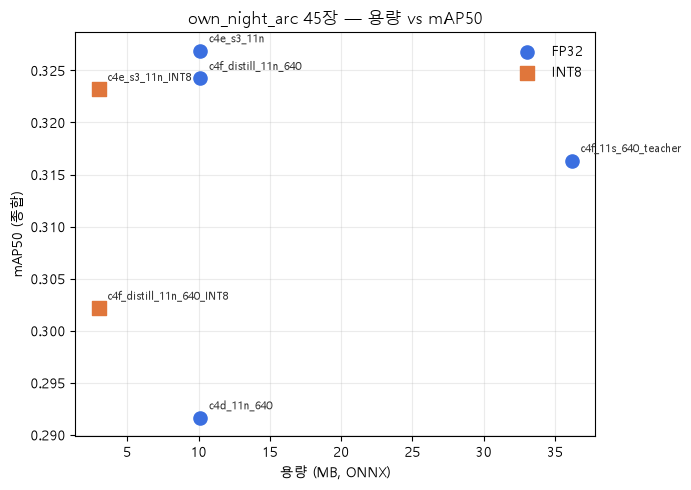

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
is_int8 = summary_df.index.str.endswith("INT8")

ax.scatter(summary_df.loc[~is_int8, "용량(MB, ONNX)"], summary_df.loc[~is_int8, "mAP50(종합)"],
           s=90, marker="o", color="#3B6FE0", label="FP32", zorder=3)
ax.scatter(summary_df.loc[is_int8, "용량(MB, ONNX)"], summary_df.loc[is_int8, "mAP50(종합)"],
           s=90, marker="s", color="#E0763B", label="INT8", zorder=3)

for name, row in summary_df.iterrows():
    ax.annotate(name, (row["용량(MB, ONNX)"], row["mAP50(종합)"]),
               textcoords="offset points", xytext=(6, 6), fontsize=8, color="#333333")

ax.set_xlabel("용량 (MB, ONNX)")
ax.set_ylabel("mAP50 (종합)")
ax.set_title(f"own_night_arc {cached['n_images']}장 — 용량 vs mAP50")
ax.grid(True, alpha=0.25, zorder=0)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()